# Multiple Linear Regression - Solar Wastage
Train and evaluate a Multiple Linear Regression model using features_regression_ready.csv.

In [2]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
# Define file paths (relative to notebooks/training/)
DATA_PATH = Path('../../data/processed/features_regression_ready.csv')
MODEL_PATH = Path('../../models/linear_regression_pipeline.pkl')
METRICS_PATH = Path('../../models/linear_regression_metrics.json')
RANDOM_STATE = 42

In [4]:
df = pd.read_csv(DATA_PATH)
target_col = 'wasted_energy_kwh'
X = df.drop(columns=[target_col])
y = df[target_col]
categorical_cols = ['household', 'season', 'district']
numerical_cols = [c for c in X.columns if c not in categorical_cols]
X.head()

,daily_pv_kwh,daily_load_kwh,household,year,month,day,quarter,day_of_week,day_of_year,week_of_year,...,load_rolling_mean_14d,pv_rolling_std_14d,wastage_rolling_mean_14d,pv_rolling_mean_30d,load_rolling_mean_30d,pv_rolling_std_30d,wastage_rolling_mean_30d,district,irradiance,temp
0,0.010838,0.018602,residential1,2015,5,21,2,3,141,21,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,Colombo,5.6695,26.91
1,0.555957,0.214720,residential1,2015,5,22,2,4,142,21,...,0.018602,0.000000,0.0,0.010838,0.018602,0.000000,0.0,Colombo,6.0698,27.17
2,1.382767,0.409031,residential1,2015,5,23,2,5,143,21,...,0.116661,0.385457,0.0,0.283398,0.116661,0.385457,0.0,Colombo,4.5922,27.20
3,2.177085,0.574465,residential1,2015,5,24,2,6,144,21,...,0.214118,0.690768,0.0,0.649854,0.214118,0.690768,0.0,Colombo,6.2059,27.32
4,2.962496,0.684174,residential1,2015,5,25,2,0,145,22,...,0.304204,0.949324,0.0,1.031662,0.304204,0.949324,0.0,Colombo,6.1730,27.30


In [5]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [7]:
model = LinearRegression()
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [8]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)            # R-squared (coefficient of determination)
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = root_mean_squared_error(y_test, y_pred)  # Root Mean Squared Error

# Display results
print('LinearRegression Results')
print('=' * 50)
print(f'R2:   {r2:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

LinearRegression Results
R2:   1.0000
MAE:  0.0602
RMSE: 0.5318


In [9]:
metrics = {'R2': float(r2), 'MAE': float(mae), 'RMSE': float(rmse)}
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, MODEL_PATH)
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print('Saved:', MODEL_PATH, METRICS_PATH)

Saved: ..\..\models\linear_regression_pipeline.pkl ..\..\models\linear_regression_metrics.json


## Plot: Actual vs Predicted
Visualize model performance by comparing actual wastage values against predictions.

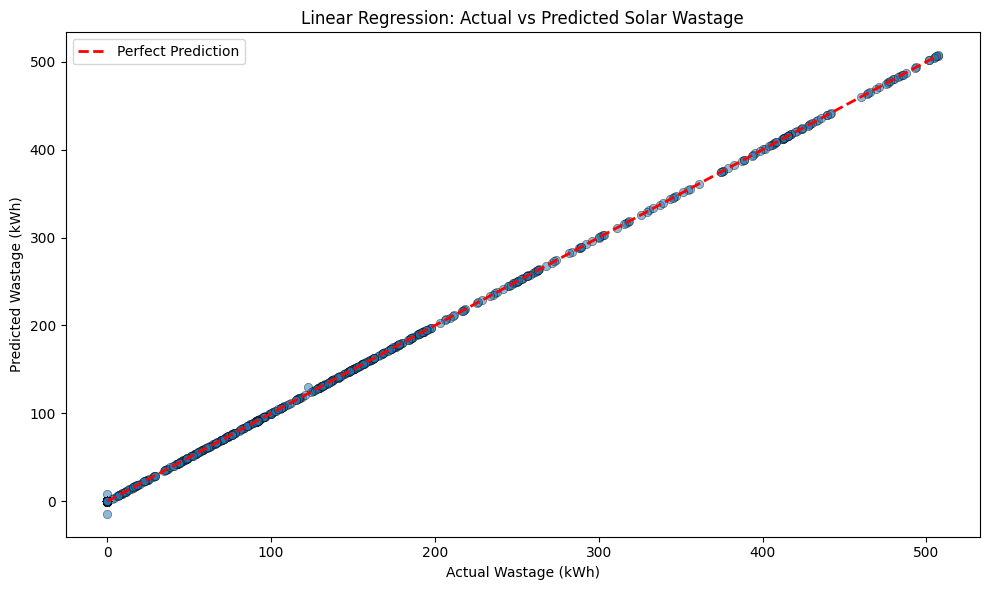

In [10]:
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Wastage (kWh)')
plt.ylabel('Predicted Wastage (kWh)')
plt.title('Linear Regression: Actual vs Predicted Solar Wastage')
plt.legend()
plt.tight_layout()
plt.savefig('../../results/linear_regression_predictions.png', dpi=150)
plt.show()

## Prediction Function
A reusable function to predict solar energy wastage from new input data.

In [11]:
def predict_wastage(new_data_dict, model_path=MODEL_PATH):
    """
    Predict solar energy wastage from input features.
    
    Parameters:
        new_data_dict: Dictionary containing feature values.
                       Must include: daily_pv_kwh, daily_load_kwh, household, 
                       season, district, irradiance, temp.
                       Other features default to 0.
        model_path: Path to the saved pipeline .pkl file.
        
    Returns:
        Predicted wasted_energy_kwh (float), capped at 0 minimum.
    """
    # Get all feature names from training data
    feature_names = X.columns.tolist()
    
    # Initialize all features with default value 0
    row = {name: 0.0 for name in feature_names}
    
    # Update with user-provided values
    for key, value in new_data_dict.items():
        if key in row:
            row[key] = value
    
    # Convert to DataFrame
    input_df = pd.DataFrame([row])
    
    # Load model and predict
    loaded_pipeline = joblib.load(model_path)
    prediction = loaded_pipeline.predict(input_df)[0]
    
    # Wastage cannot be negative
    return max(0.0, float(prediction))


# Example usage
example_input = {
    'daily_pv_kwh': 5.0,
    'daily_load_kwh': 3.0,
    'irradiance': 5.5,
    'temp': 28.0,
    'district': 'Colombo',
    'season': 'Southwest_Monsoon',
    'household': 'residential1'
}

predicted_wastage = predict_wastage(example_input)
print(f"Example prediction: {predicted_wastage:.4f} kWh")

Example prediction: 24.0229 kWh
